In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import time
import math
import seaborn as sns
from datetime import datetime,timedelta
import requests
import folium

In [2]:
city_name = input("Enter the city name: ");
api_key = "672bf268a2c77bfbfb6e36d7a4c01d84"
url = f"https://api.openweathermap.org/data/2.5/forecast?q={city_name}&appid={api_key}";

Enter the city name:  Kuala Lumpur


In [3]:
response = requests.get(url)
response

<Response [200]>

In [4]:
if response.status_code == 200:
    data = response.json()

In [5]:
len(data)

5

In [6]:
#print(data)

In [7]:
data.keys()

dict_keys(['cod', 'message', 'cnt', 'list', 'city'])

In [8]:
cordinates = data["city"]["coord"]
print(cordinates)

{'lat': 3.1431, 'lon': 101.6865}


In [9]:
latitude = cordinates["lat"]
longitude = cordinates["lon"]

print(latitude)
print(longitude)

3.1431
101.6865


In [10]:
weather_data = data["list"]

In [11]:
# for i in weather_data:
#     print(i.keys())

In [12]:
len(weather_data)

40

In [13]:
 # for i in range(len(weather_data)):
 #    print(type(weather_data[i]['dt_txt']))
 #    print(weather_data[i]['dt_txt'])

In [14]:
# for i in weather_data:
#     print(i)

In [15]:
main_data = weather_data[0]["main"]
main_data

{'temp': 301.05,
 'feels_like': 301.24,
 'temp_min': 301.05,
 'temp_max': 301.2,
 'pressure': 1006,
 'sea_level': 1006,
 'grnd_level': 993,
 'humidity': 47,
 'temp_kf': -0.15}

In [16]:
weather = weather_data[0]["weather"]
weather

[{'id': 501, 'main': 'Rain', 'description': 'moderate rain', 'icon': '10d'}]

In [17]:
wind = weather_data[0]["wind"]
wind

{'speed': 1.03, 'deg': 251, 'gust': 1.64}

In [18]:
#rain = weather_data[0]["rain"]
#rain

In [19]:
isRain = weather[0]["main"]
isRain

'Rain'

In [20]:
# for i in range(len(weather_data)):
#     print(weather_data[i]["weather"][0]["main"])

In [21]:
temprature = []
humidity = []
main_data = []
description = []
wind_speed = []
rain_mm = []
time = []
for i in range(len(weather_data)):
    temp_value = round(weather_data[i]["main"]["temp"]-273.15,2)
    humi_value = weather_data[i]["main"]["humidity"]
    main_value = weather_data[i]["weather"][0]["main"]
    descri_value = weather_data[i]["weather"][0]["description"]
    wind_value = round(weather_data[i]["wind"]["speed"]*3.6,2)
    time_value = weather_data[i]["dt_txt"]

    temprature.append(temp_value)
    humidity.append(humi_value)
    main_data.append(main_value)
    description.append(descri_value)
    wind_speed.append(wind_value)
    time.append(time_value)
    if weather_data[i]["weather"][0]["main"] == "Rain":
        rain_value = weather_data[i]["rain"]["3h"]*10
        rain_mm.append(rain_value)
    else:
        rain_mm.append(0)

df = pd.DataFrame({
    "Temperature":temprature,
    "Humidity":humidity,
    "Wind Speed":wind_speed,
    "Rain value(mm)":rain_mm,
    "Time":time
})
df["Time"] = pd.to_datetime(df["Time"])

In [22]:
# print(df)

In [23]:
def rain_flood_prediction():
    temprature = []
    humidity = []
    main_data = []
    description = []
    wind_speed = []
    rain_mm = []
    for i in range(len(weather_data)):
        temp_value = round(weather_data[i]["main"]["temp"]-273.15,2)
        humi_value = weather_data[i]["main"]["humidity"]
        main_value = weather_data[i]["weather"][0]["main"]
        descri_value = weather_data[i]["weather"][0]["description"]
        wind_value = weather_data[i]["wind"]["speed"]

        temprature.append(temp_value)
        humidity.append(humi_value)
        main_data.append(main_value)
        description.append(descri_value)
        wind_speed.append(wind_value)
        if weather_data[i]["weather"][0]["main"] == "Rain":
            rain_value = weather_data[i]["rain"]["3h"]*10
            rain_mm.append(rain_value)
        else:
            rain_mm.append(0)
    for i in range(len(temprature)):
        print(f"Temparature of {city_name} is: {temprature[i]}\u00B0C")
        print(f"Humidity of {city_name} is: {humidity[i]}")
        print(f"Main discription of {city_name} is: {main_data[i]}")
        print(f"Description of {city_name} is: {description[i]}")
        print(f"Wind speed of {city_name} is: {wind_speed[i]}")
        print("-----------------------------------------------------")

    daily_rain = []
    daily_hum = []
    daily_temp = []
    for i in range(0, 40, 8):
        day_total = sum(rain_mm[i:i+8])
        daily_rain.append(day_total)
        day_hum = float(np.mean(humidity[i:i+8]))
        daily_hum.append(round(day_hum,2))
        day_temp = float(np.mean(temprature[i:i+8]))
        daily_temp.append(round(day_temp,2))

    print("---------------------------------------------------------")
    print(f'5 Days Daily Rainfall of {city_name} is: {daily_rain}')
    print(f"Total Rainfall in 5 Days of {city_name} is: {sum(daily_rain)}")
    print(f"Maximum Rainfall in Daily Rain of {city_name} is: {max(daily_rain)}")
    print(f"Maximum 3-Hours rainfall of{city_name} is: {max(rain_mm)}")
    print("*--*"*20)
    for i in range(len(daily_rain)):
        rain = daily_rain[i]
        hum = daily_hum[i]
        temp = daily_temp[i]
        if rain > 200 and hum > 90 and temp < 20:
            result = "High Risk Flood"
        elif rain >= 50 and hum > 85:
            result = "Flood Likely Happened"
        else:
            result = "No Flood"
    
        print(f"Day {i+1} → {result}")
        

In [24]:
def show_visualization():
    #Line Plot Visualzation
    plt.figure(figsize=(12,6))
    plt.plot(df.index, df["Temperature"], label="Temperature")
    plt.plot(df.index, df["Humidity"], label="Humidity")
    plt.plot(df.index, df["Wind Speed"], label="Wind Speed(km/h)")
    
    plt.title("Weather Trends Over Time")
    plt.xlabel("Time")
    plt.ylabel("Values")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.grid()
    plt.show()

    #Scatter Plot Visualization
    plt.figure(figsize=(8,6))
    plt.scatter(df["Temperature"], df["Humidity"])
    plt.title("Temperature vs Humidity")
    plt.xlabel("Temperature")
    plt.ylabel("Humidity")
    plt.grid()
    plt.show()

    #Rain Visualization
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df["Rain value(mm)"], marker='o')
    plt.title("Rain Occurrence (1 = Rain, 0 = No Rain)")
    plt.xlabel("Time")
    plt.ylabel("Rain")
    plt.grid()
    plt.xticks(rotation=45)
    plt.show()

    #Heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

    #Pai plot Visualization
    sns.pairplot(df)
    plt.show()

    #Flood Risking Visualization 
    df["Flood Risk"] = ((df["Rain value(mm)"] == 1) & (df["Humidity"] > 80)).astype(int)
    plt.figure(figsize=(12,4))
    plt.plot(df.index, df["Flood Risk"], color="red")
    plt.title("Flood Risk Prediction")
    plt.xlabel("Time")
    plt.ylabel("Risk (1 = High)")
    plt.xticks(rotation=45)
    plt.show()


True
Temparature of Kuala Lumpur is: 27.9°C
Humidity of Kuala Lumpur is: 47
Main discription of Kuala Lumpur is: Rain
Description of Kuala Lumpur is: moderate rain
Wind speed of Kuala Lumpur is: 1.03
-----------------------------------------------------
Temparature of Kuala Lumpur is: 28.01°C
Humidity of Kuala Lumpur is: 61
Main discription of Kuala Lumpur is: Rain
Description of Kuala Lumpur is: moderate rain
Wind speed of Kuala Lumpur is: 0.72
-----------------------------------------------------
Temparature of Kuala Lumpur is: 27.66°C
Humidity of Kuala Lumpur is: 77
Main discription of Kuala Lumpur is: Rain
Description of Kuala Lumpur is: moderate rain
Wind speed of Kuala Lumpur is: 1
-----------------------------------------------------
Temparature of Kuala Lumpur is: 27.23°C
Humidity of Kuala Lumpur is: 94
Main discription of Kuala Lumpur is: Rain
Description of Kuala Lumpur is: light rain
Wind speed of Kuala Lumpur is: 1.22
-----------------------------------------------------
Te

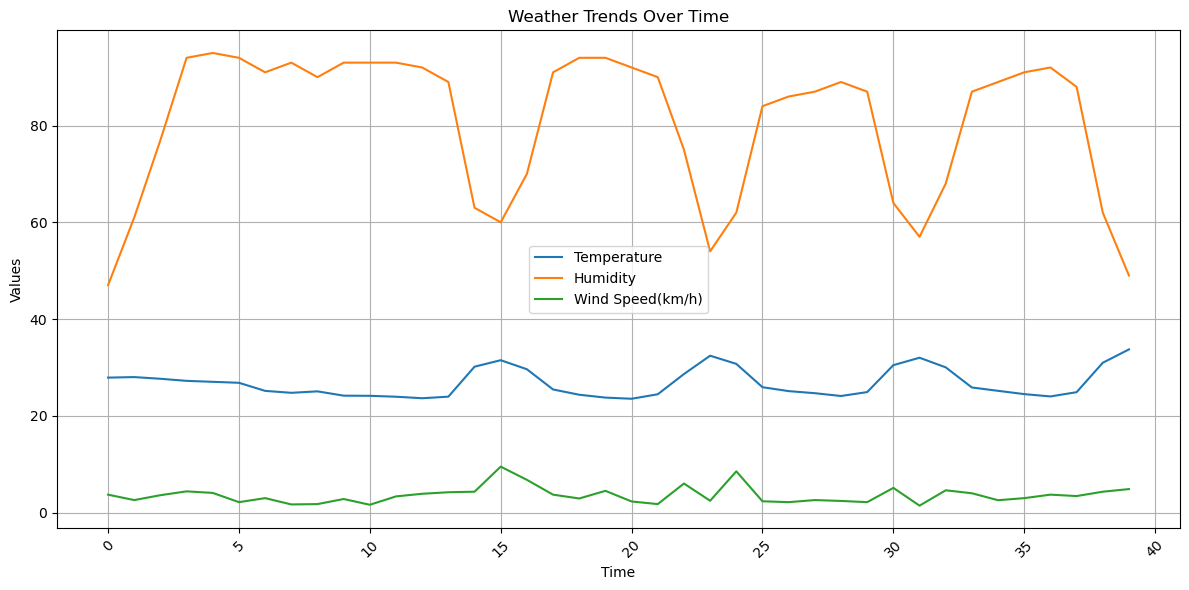

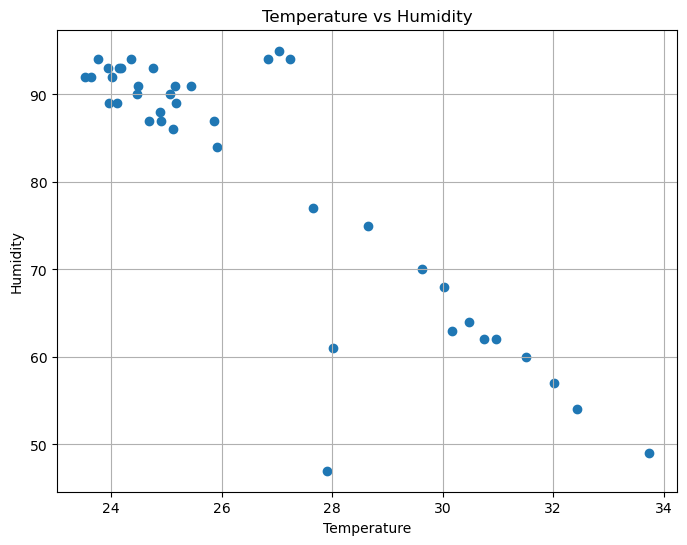

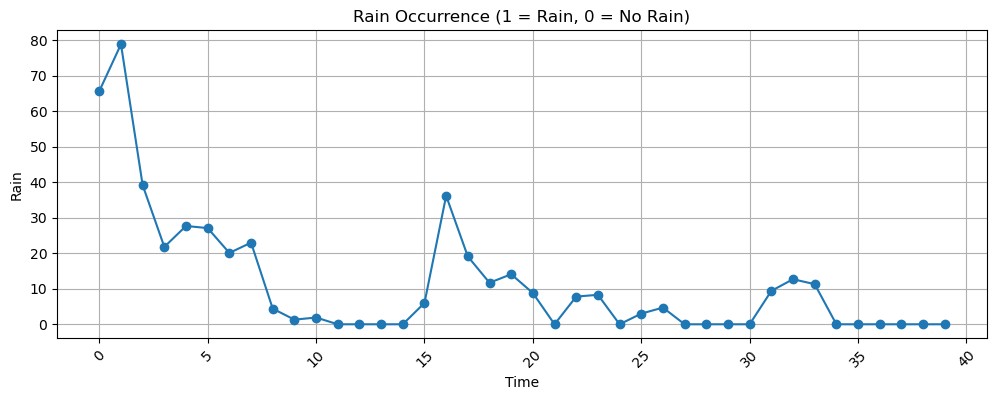

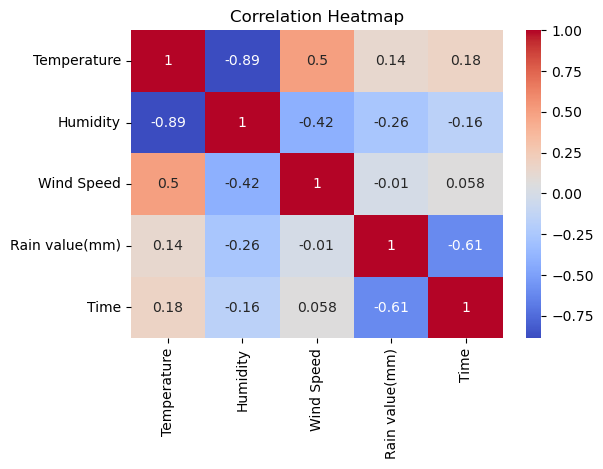

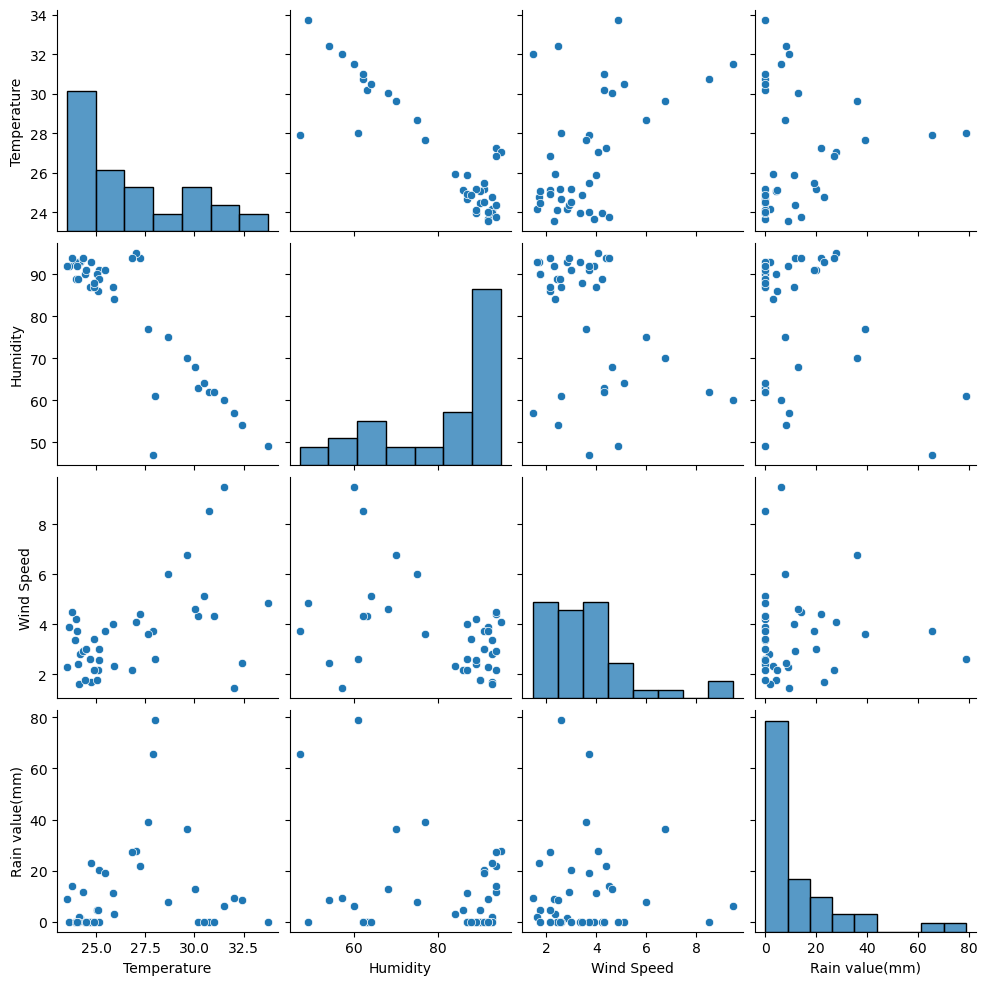

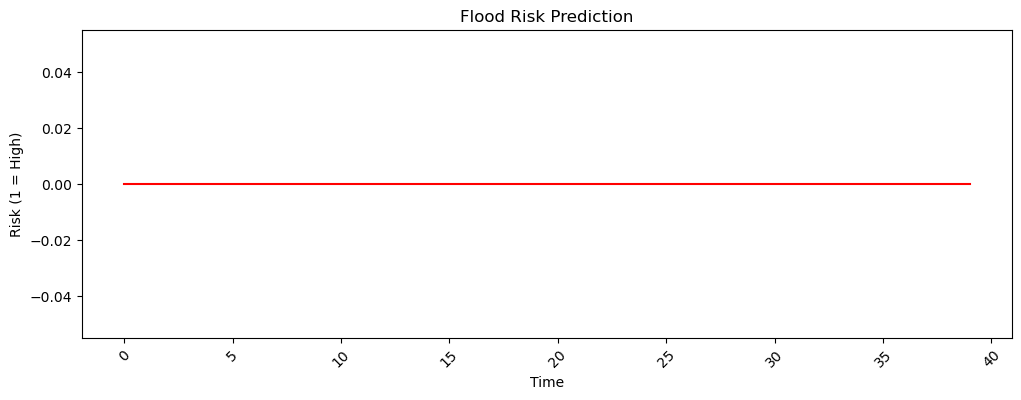

In [25]:
if isRain == "Rain":
    print("True")
    rain_flood_prediction()
    show_visualization()
else:
    print("False")
    rain_flood_prediction()
    show_visualization()

In [26]:
m = folium.Map(location=[latitude, longitude], zoom_start=10)

folium.TileLayer(
    tiles="https://maps.openweathermap.org/maps/2.0/weather/temp/{z}/{x}/{y}?appid=api_key",
    attr="OpenWeatherMap"
).add_to(m)

m

In [27]:
m = folium.Map(location=[latitude, longitude], zoom_start=10)

folium.TileLayer(
    tiles=f"https://maps.openweathermap.org/maps/2.0/weather/temp/{{z}}/{{x}}/{{y}}?appid={api_key}",
    attr="OpenWeatherMap",
    name="Temperature",
    overlay=True,
    control=True
).add_to(m)

folium.LayerControl().add_to(m)

m